# BiGRU + Flatten — Baseline & GWO-Optimised Pipeline
## Architecture: `Embedding → BiGRU (Bidirectional) → Flatten → Dense`
### Unified, refactored notebook merging baseline training and Grey Wolf Optimizer (GWO) hyperparameter tuning

| Section | Description |
|---|---|
| 1 | Imports & Environment |
| 2 | Configuration |
| 3 | Reproducibility & GPU Setup |
| 4 | Data Loading |
| 5 | Dataset Statistics |
| 6 | Model Builder |
| 7 | Evaluation Utilities |
| 8 | Baseline Training Pipeline |
| 9 | GWO Optimisation |
| 10 | Final Model (Optimised) |
| 11 | Evaluation & Comparison |
| 12 | Visualisation |

---
**Author**: ML Engineering Team | **Date**: March 2026  
**Fixes & Improvements**: see inline `# FIX` / `# IMPROVEMENT` comments

In [11]:
import os
import gc


# Environment Variables 

os.environ["CUDA_VISIBLE_DEVICES"] = "0"        # Use GPU 0 and 1; set "0" for single GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"           # Suppress TF C++ logs (INFO/WARNING)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"          # Disable OneDNN for numerical stability
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"



# Standard Library Imports

import warnings
import random
import time
from datetime import timedelta
from typing import Dict, Tuple, List, Optional


# Third-Party Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU,Flatten ,Bidirectional, Dense 
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, accuracy_score
)

from mealpy.swarm_based.GWO import OriginalGWO
from mealpy import FloatVar, IntegerVar

warnings.filterwarnings("ignore")

print(f"TensorFlow version : {tf.__version__}")
print(f"CUDA built         : {tf.test.is_built_with_cuda()}")
print("All imports successful.")


TensorFlow version : 2.15.0
CUDA built         : True
All imports successful.


In [12]:

# Random Seed Configuration

RANDOM_STATE = 116


gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices found: {len(gpus)}")
for gpu in gpus:
    print(f"  {gpu}")

def set_seeds(seed: int = RANDOM_STATE) -> None:
    """Set all random seeds for full reproducibility."""
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)  # Hash-based ops (dicts, sets)


set_seeds(RANDOM_STATE)



GPU devices found: 0


In [13]:

# Dataset Paths — Update paths to match your environment

DATA_PATHS = {
    "train": "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/train_set_balanced.xlsx",
    "val"  : "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/val_set_balanced.xlsx",
    "test" : "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/test_set_balanced.xlsx",
}


# Training Hyperparameters (Baseline)

EPOCHS      = 100
PATIENCE    = 5
RANDOM_STATE = 116

BASELINE_PARAMS = {
    "learning_rate": 3e-4,
    "batch_size"   : 256,
    "gru_units"    : 32,
    "dropout"      : 0.3,
}


# GWO Search Space & Configuration

GWO_CONFIG = {
    "pop_size": 10,
    "epoch"   : 10,
}

SEARCH_SPACE = {
    "learning_rate": (1e-5, 1e-2),
    "batch_size"   : (64, 512),
    "gru_units"    : (16, 128),
    "dropout"      : (0.1, 0.5),
}


# Output Directories

MODEL_NAME  = "BiGRU_Baseline"

DIRS = {
    "models" : "./models",
    "results": "./results",
    "plots"  : "./plots",
    "gwo"    : "./gwo_results",
    "images" : "./images",
}

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

# Derived save paths
BASELINE_MODEL_PATH  = f"{DIRS['models']}/{MODEL_NAME}_baseline.keras"
OPTIMIZED_MODEL_PATH = f"{DIRS['models']}/{MODEL_NAME}_optimized.keras"
MODEL_ARCHITECTURE   = f"{DIRS['images']}/{MODEL_NAME}_architecture.png"

print("Configuration loaded.")
print(f"  Baseline model will save to : {BASELINE_MODEL_PATH}")
print(f"  Optimized model will save to: {OPTIMIZED_MODEL_PATH}")


Configuration loaded.
  Baseline model will save to : ./models/BiGRU_Baseline_baseline.keras
  Optimized model will save to: ./models/BiGRU_Baseline_optimized.keras


In [14]:
# SECTION 4 — DATA LOADING

def load_dataset(path: str, name: str) -> Tuple[np.ndarray, np.ndarray]:
    """Load dataset from Excel file and return features and labels as NumPy arrays."""
    
    df = pd.read_excel(path)

    X = df.drop(columns="labels").apply(pd.to_numeric, errors="coerce").fillna(0)
    y = pd.to_numeric(df["labels"], errors="coerce").fillna(0)

    X = np.asarray(X, dtype=np.int32)
    y = np.asarray(y, dtype=np.int32)

    label_counts = pd.Series(y).value_counts().rename(index={0: "Negative", 1: "Positive"})

    print(f"{name.upper():5s} | samples={X.shape[0]:,}  seq_len={X.shape[1]}  ", end="")
    print(f"dtype: X={X.dtype} y={y.dtype}")
    print(f"       label dist: {label_counts.to_dict()}")

    return X, y



# Load Datasets

print("LOADING DATASETS")


X_train, y_train = load_dataset(DATA_PATHS["train"], "train")
X_val,   y_val   = load_dataset(DATA_PATHS["val"],   "val")
X_test,  y_test  = load_dataset(DATA_PATHS["test"],  "test")


LOADING DATASETS
TRAIN | samples=8,260  seq_len=271  dtype: X=int32 y=int32
       label dist: {'Negative': 4167, 'Positive': 4093}
VAL   | samples=1,806  seq_len=271  dtype: X=int32 y=int32
       label dist: {'Positive': 913, 'Negative': 893}
TEST  | samples=1,833  seq_len=271  dtype: X=int32 y=int32
       label dist: {'Positive': 940, 'Negative': 893}


In [15]:

# Vocabulary Size & Sequence Length

VOCAB_SIZE = int(max(X_train.max(), X_val.max(), X_test.max()))
MAX_LEN    = X_train.shape[1]

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"Training samples  : {X_train.shape[0]:,}")
print(f"Validation samples: {X_val.shape[0]:,}")
print(f"Test samples      : {X_test.shape[0]:,}")
print(f"Vocabulary size   : {VOCAB_SIZE:,}")
print(f"Sequence length   : {MAX_LEN}")
print(f"Positive (train)  : {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Positive (val)    : {y_val.sum():,}   ({y_val.mean()*100:.1f}%)")
print(f"Positive (test)   : {y_test.sum():,}  ({y_test.mean()*100:.1f}%)")
print("=" * 60)


DATASET STATISTICS
Training samples  : 8,260
Validation samples: 1,806
Test samples      : 1,833
Vocabulary size   : 132
Sequence length   : 271
Positive (train)  : 4,093 (49.6%)
Positive (val)    : 913   (50.6%)
Positive (test)   : 940  (51.3%)


In [16]:

# SECTION 6 — MODEL BUILDER


def build_model(
    vocab_size:  int,
    max_len:     int,
    gru_units:   int   = 32,
    dropout:     float = 0.3,
    embed_dim:   int   = 128,
    lr:          float = 3e-4,
    name:        str   = "BiGRU_Flatten",
    compile_model: bool = True,
) -> Sequential:

    set_seeds()

    model = Sequential([
        # Token embedding (mask_zero=False keeps Flatten layer safe)
        Embedding(
            input_dim=vocab_size + 1,
            output_dim=embed_dim,
            input_length=max_len,
            mask_zero=False,
        ),
        # Bidirectional GRU — return_sequences=False → 2D output
        Bidirectional(
            GRU(gru_units, return_sequences=False, dropout=dropout),
            name="bigru"
        ),
        # Flatten is architecturally deliberate (see note above)
        Flatten(name="flatten"),
        # Binary classification head
        Dense(1, activation="sigmoid", name="output"),
    ], name="BiGRU_Flatten_GWO")

    return model


# Preview architecture

_preview = build_model(VOCAB_SIZE, MAX_LEN)
_preview.build(input_shape=(None, MAX_LEN))
_preview.summary()

plot_model(_preview, to_file=MODEL_ARCHITECTURE, show_shapes=True, show_layer_names=True)
print(f"Architecture diagram saved to: {MODEL_ARCHITECTURE}")
del _preview
gc.collect()


Model: "BiGRU_Flatten_GWO"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 bigru (Bidirectional)       (None, 64)                31104     
                                                                 
 flatten (Flatten)           (None, 64)                0         
                                                                 
 output (Dense)              (None, 1)                 65        
                                                                 
Total params: 48193 (188.25 KB)
Trainable params: 48193 (188.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Architecture diagram saved to: ./images/BiGRU_Baseline_architecture.png


6686

In [17]:
class ClassificationMetrics:
    """
    Compute and store standard binary classification metrics.

    Usage
    -----
    cm = ClassificationMetrics(y_true, y_pred)
    print(cm.report())
    """

    def __init__(self, y_true: np.ndarray, y_pred: np.ndarray) -> None:
        self.y_true = y_true.flatten()
        self.y_pred = y_pred.flatten()
        self._cm    = confusion_matrix(self.y_true, self.y_pred)

    def confusion_matrix(self) -> np.ndarray:
        return self._cm

    def tp(self) -> int:
        return int(self._cm[1, 1])

    def tn(self) -> int:
        return int(self._cm[0, 0])

    def fp(self) -> int:
        return int(self._cm[0, 1])

    def fn(self) -> int:
        return int(self._cm[1, 0])

    def precision(self) -> float:
        return float(precision_score(self.y_true, self.y_pred, zero_division=0))

    def recall(self) -> float:
        return float(recall_score(self.y_true, self.y_pred, zero_division=0))

    def f1(self) -> float:
        return float(f1_score(self.y_true, self.y_pred, zero_division=0))

    def accuracy(self) -> float:
        return float(accuracy_score(self.y_true, self.y_pred))

    def as_dict(self) -> Dict:
        return {
            "Accuracy" : self.accuracy(),
            "Precision": self.precision(),
            "Recall"   : self.recall(),
            "F1-Score" : self.f1(),
            "TP": self.tp(), "TN": self.tn(),
            "FP": self.fp(), "FN": self.fn(),
        }

    def report(self, title: str = "Classification Metrics") -> str:
        d = self.as_dict()
        lines = ["=" * 50, title, "=" * 50]
        for k, v in d.items():
            lines.append(f"  {k:<12}: {v:.4f}" if isinstance(v, float) else f"  {k:<12}: {v}")
        lines.append("=" * 50)
        return "".join(lines)



# Utility

def to_numpy(x) -> np.ndarray:
    """Convert pandas DataFrame/Series to numpy array if needed."""    
    return x.values if hasattr(x, "values") else x


print("Helper classes/functions defined.")


Helper classes/functions defined.


In [18]:

# Clear any previous session before baseline training

tf.keras.backend.clear_session()
gc.collect()
set_seeds(RANDOM_STATE)
tf.config.optimizer.set_jit(False)   # Disable XLA/JIT (prevents libdevice errors)

print("=" * 60)
print("BASELINE MODEL TRAINING")
print("=" * 60)
print(f"  LR={BASELINE_PARAMS['learning_rate']}  Batch={BASELINE_PARAMS['batch_size']}  ", end="")
print(f"GRU={BASELINE_PARAMS['gru_units']}  Dropout={BASELINE_PARAMS['dropout']}")
print("=" * 60)

# Build 
baseline_model = build_model(
    vocab_size = VOCAB_SIZE,
    max_len    = MAX_LEN,
    gru_units  = BASELINE_PARAMS["gru_units"],
    dropout    = BASELINE_PARAMS["dropout"],
)

# Compile 
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2)

baseline_model.compile(
    optimizer  = Adam(learning_rate=BASELINE_PARAMS["learning_rate"]),
    loss       = loss_fn,
    metrics    = ["accuracy", tf.keras.metrics.AUC(name="auc")],
    run_eagerly= False,
)

baseline_model.build(input_shape=(None, MAX_LEN))
baseline_model.summary()

# Callbacks 
baseline_callbacks = [
    EarlyStopping(
        monitor             = "val_auc",
        mode                = "max",
        patience            = PATIENCE,
        restore_best_weights= True,
        verbose             = 1,
    ),
    ModelCheckpoint(
        filepath       = BASELINE_MODEL_PATH,
        monitor        = "val_auc",
        mode           = "max",
        save_best_only = True,
        verbose        = 1,
    ),
]

# Train 
baseline_start = time.time()

baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS ,
    batch_size      = BASELINE_PARAMS["batch_size"],
    callbacks       = baseline_callbacks,
    verbose         = 2,
)

baseline_time = time.time() - baseline_start

print(f"Baseline training completed in {str(timedelta(seconds=int(baseline_time)))}")
print(f"Best model saved to: {BASELINE_MODEL_PATH}")


BASELINE MODEL TRAINING
  LR=0.0003  Batch=256  GRU=32  Dropout=0.3
Model: "BiGRU_Flatten_GWO"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 bigru (Bidirectional)       (None, 64)                31104     
                                                                 
 flatten (Flatten)           (None, 64)                0         
                                                                 
 output (Dense)              (None, 1)                 65        
                                                                 
Total params: 48193 (188.25 KB)
Trainable params: 48193 (188.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/100

Epoch 1: val_auc improved from -inf to 0.84855, saving model t

In [19]:

# Baseline Evaluation


# Validation set
baseline_val_pred = (baseline_model.predict(X_val, verbose=0) > 0.5).astype(int).flatten()
baseline_val_cm   = ClassificationMetrics(y_val, baseline_val_pred)

# Test set
baseline_test_pred = (baseline_model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
baseline_test_cm   = ClassificationMetrics(y_test, baseline_test_pred)

print(baseline_val_cm.report("BASELINE — Validation Set"))
print()
print(baseline_test_cm.report("BASELINE — Test Set"))
print(f"Training time: {str(timedelta(seconds=int(baseline_time)))}")


==================================================BASELINE — Validation Set==================================================  Accuracy    : 0.9147  Precision   : 0.9611  Recall      : 0.8664  F1-Score    : 0.9113  TP          : 791  TN          : 861  FP          : 32  FN          : 122==================================================

==================================================BASELINE — Test Set==================================================  Accuracy    : 0.9116  Precision   : 0.9492  Recall      : 0.8745  F1-Score    : 0.9103  TP          : 822  TN          : 849  FP          : 44  FN          : 118==================================================
Training time: 0:01:06


In [20]:
gc.collect()
# Search Space 

gwo_bounds = [
    FloatVar  (lb=SEARCH_SPACE["learning_rate"][0], ub=SEARCH_SPACE["learning_rate"][1], name="learning_rate"),
    IntegerVar(lb=SEARCH_SPACE["batch_size"][0],    ub=SEARCH_SPACE["batch_size"][1],    name="batch_size"),
    IntegerVar(lb=SEARCH_SPACE["gru_units"][0],     ub=SEARCH_SPACE["gru_units"][1],     name="gru_units"),
    FloatVar  (lb=SEARCH_SPACE["dropout"][0],       ub=SEARCH_SPACE["dropout"][1],       name="dropout"),
]

print("GWO Search Space:")
for k, (lo, hi) in SEARCH_SPACE.items():
    print(f"  {k:<15}: [{lo}, {hi}]")


# Optimization State 

_gwo_iteration   = 0
_gwo_best_f1     = 0.0
_optimization_log: List[Dict] = []


def objective_function(solution: np.ndarray) -> float:

    global _gwo_iteration, _gwo_best_f1

    _gwo_iteration += 1

    lr         = float(solution[0])
    batch_size = int(np.clip(round(solution[1]), 32, 512))
    gru_units  = int(np.clip(round(solution[2]),  8, 128))
    dropout    = float(solution[3])

    print(f"[GWO iter {_gwo_iteration:>3}] LR={lr:.2e}  Batch={batch_size}  GRU={gru_units}  Drop={dropout:.3f}", end="  ")

    try:
        tf.keras.backend.clear_session()
        gc.collect()

        set_seeds(RANDOM_STATE)

        model = build_model(VOCAB_SIZE, MAX_LEN, gru_units=gru_units, dropout=dropout)

        loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2)
        model.compile(
            optimizer   = Adam(learning_rate=lr),
            loss        = loss_fn,
            metrics     = ["accuracy", tf.keras.metrics.AUC(name="auc")],
            run_eagerly = False,
        )

        early_stop = EarlyStopping(
            monitor              = "val_auc",
            mode                 = "max",
            patience             = 3,
            restore_best_weights = True,
            verbose              = 0,
        )

        hist = model.fit(
            X_train, y_train,
            validation_data = (X_val, y_val),
            epochs          = 30,            
            batch_size      = batch_size,
            callbacks       = [early_stop],
            verbose         = 0,
        )

        y_pred  = (model.predict(X_val, verbose=0) > 0.5).astype(int).flatten()
        f1_val  = f1_score(y_val, y_pred, zero_division=0)
        acc_val = accuracy_score(y_val, y_pred)

        if f1_val > _gwo_best_f1:
            _gwo_best_f1 = f1_val
            print(f"NEW BEST  F1={f1_val:.4f}  Acc={acc_val:.4f}")
        else:
            print(f"F1={f1_val:.4f}  Acc={acc_val:.4f}")

        _optimization_log.append({
            "iteration"   : _gwo_iteration,
            "learning_rate": lr,
            "batch_size"  : batch_size,
            "gru_units"   : gru_units,
            "dropout"     : dropout,
            "f1_score"    : f1_val,
            "accuracy"    : acc_val,
            "epochs_run"  : len(hist.history["loss"]),
            "train_loss"  : float(hist.history["loss"][-1]),
        })

        return -f1_val   # GWO minimises

    except Exception as exc:
        print(f"ERROR: {exc}")
        return 0.0       # Worst possible fitness


print("Objective function defined.")
tf.keras.backend.clear_session()
gc.collect()
print("section 7 code ready to run.")


GWO Search Space:
  learning_rate  : [1e-05, 0.01]
  batch_size     : [64, 512]
  gru_units      : [16, 128]
  dropout        : [0.1, 0.5]
Objective function defined.
section 7 code ready to run.


In [21]:
# ============================================================
# SECTION 9c — RUN GWO
# ============================================================

print("\n" + "=" * 60)
print("GREY WOLF OPTIMIZER — HYPERPARAMETER SEARCH")
print("=" * 60)
print(f"  Population size  : {GWO_CONFIG['pop_size']}")
print(f"  Optimizer epochs : {GWO_CONFIG['epoch']}")
print("=" * 60 + "\n")

problem_dict = {
    "obj_func": objective_function,
    "bounds":   gwo_bounds,
    "minmax":   "min",
}

gwo_optimizer = OriginalGWO(
    epoch    = GWO_CONFIG["epoch"],
    pop_size = GWO_CONFIG["pop_size"],
)

gwo_start = time.time()
g_best     = gwo_optimizer.solve(problem_dict)
gwo_elapsed= time.time() - gwo_start

best_solution = g_best.solution
best_fitness  = g_best.target.fitness   # negative F1

print("\n" + "=" * 60)
print("GWO OPTIMISATION COMPLETE")
print("=" * 60)
print(f"  Elapsed time : {str(timedelta(seconds=int(gwo_elapsed)))}")
print(f"  Best val F1  : {-best_fitness:.4f}")
print("=" * 60)

log_df = pd.DataFrame(_optimization_log)
gwo_log_path = f"{DIRS['gwo']}/{MODEL_NAME}_gwo_log.csv"
log_df.to_csv(gwo_log_path, index=False)
print(f"Optimisation log saved to: {gwo_log_path}")
gc.collect()

2026/03/25 08:43:24 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=10, pop_size=10)



GREY WOLF OPTIMIZER — HYPERPARAMETER SEARCH
  Population size  : 10
  Optimizer epochs : 10

[GWO iter   1] LR=3.40e-03  Batch=409  GRU=37  Drop=0.360  NEW BEST  F1=0.9206  Acc=0.9252
[GWO iter   2] LR=1.62e-03  Batch=310  GRU=21  Drop=0.351  F1=0.9144  Acc=0.9186
[GWO iter   3] LR=2.10e-03  Batch=494  GRU=44  Drop=0.362  F1=0.9039  Acc=0.9092
[GWO iter   4] LR=1.47e-03  Batch=325  GRU=49  Drop=0.497  NEW BEST  F1=0.9262  Acc=0.9297
[GWO iter   5] LR=2.30e-03  Batch=269  GRU=115  Drop=0.288  NEW BEST  F1=0.9282  Acc=0.9302
[GWO iter   6] LR=2.64e-03  Batch=160  GRU=117  Drop=0.480  NEW BEST  F1=0.9356  Acc=0.9374
[GWO iter   7] LR=5.89e-03  Batch=99  GRU=127  Drop=0.381  F1=0.9334  Acc=0.9330
[GWO iter   8] LR=9.64e-03  Batch=296  GRU=35  Drop=0.133  F1=0.9330  Acc=0.9352
[GWO iter   9] LR=6.56e-03  Batch=493  GRU=52  Drop=0.266  F1=0.9333  Acc=0.9352
[GWO iter  10] LR=4.54e-03  Batch=396  GRU=98  Drop=0.347  F1=0.9244  Acc=0.9286
[GWO iter  11] LR=5.68e-03  Batch=388  GRU=60  Drop=0.

2026/03/25 09:49:16 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: -0.9370391378332388, Global best: -0.9370391378332388, Runtime: 2021.70495 seconds


NEW BEST  F1=0.9370  Acc=0.9385
[GWO iter  21] LR=1.73e-03  Batch=64  GRU=110  Drop=0.451  F1=0.9288  Acc=0.9308
[GWO iter  22] LR=4.95e-03  Batch=74  GRU=109  Drop=0.500  F1=0.9355  Acc=0.9363
[GWO iter  23] LR=5.71e-03  Batch=227  GRU=46  Drop=0.500  F1=0.9260  Acc=0.9286
[GWO iter  24] LR=2.97e-03  Batch=64  GRU=128  Drop=0.500  NEW BEST  F1=0.9399  Acc=0.9408
[GWO iter  25] LR=3.81e-03  Batch=134  GRU=57  Drop=0.500  NEW BEST  F1=0.9408  Acc=0.9424
[GWO iter  26] LR=1.58e-03  Batch=191  GRU=102  Drop=0.441  F1=0.9060  Acc=0.9120
[GWO iter  27] LR=4.29e-03  Batch=140  GRU=51  Drop=0.215  F1=0.9347  Acc=0.9347
[GWO iter  28] LR=1.36e-03  Batch=108  GRU=44  Drop=0.380  F1=0.9317  Acc=0.9347
[GWO iter  29] LR=5.13e-03  Batch=270  GRU=103  Drop=0.408  F1=0.9218  Acc=0.9258
[GWO iter  30] LR=4.35e-03  Batch=154  GRU=121  Drop=0.196  

2026/03/25 10:30:39 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: -0.9407744874715261, Global best: -0.9407744874715261, Runtime: 2453.28809 seconds


...

2026/03/25 04:03:58 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 9, Current best: -0.9459007250418293, Global best: -0.9459007250418293, Runtime: 3293.32917 seconds


F1=0.9361  Acc=0.9363
[GWO iter 101] LR=3.92e-03  Batch=122  GRU=84  Drop=0.500  F1=0.9337  Acc=0.9358
[GWO iter 102] LR=3.92e-03  Batch=122  GRU=84  Drop=0.500  F1=0.9337  Acc=0.9358
[GWO iter 103] LR=3.92e-03  Batch=122  GRU=84  Drop=0.500  F1=0.9337  Acc=0.9358
[GWO iter 104] LR=3.92e-03  Batch=122  GRU=84  Drop=0.500  F1=0.9337  Acc=0.9358
[GWO iter 105] LR=3.92e-03  Batch=122  GRU=84  Drop=0.500  F1=0.9337  Acc=0.9358
[GWO iter 106] LR=3.92e-03  Batch=122  GRU=84  Drop=0.500  F1=0.9337  Acc=0.9358
[GWO iter 107] LR=3.92e-03  Batch=122  GRU=84  Drop=0.500  F1=0.9337  Acc=0.9358
[GWO iter 108] LR=3.92e-03  Batch=122  GRU=84  Drop=0.500  F1=0.9337  Acc=0.9358
[GWO iter 109] LR=3.92e-03  Batch=122  GRU=84  Drop=0.500  F1=0.9337  Acc=0.9358
[GWO iter 110] LR=3.92e-03  Batch=122  GRU=84  Drop=0.500  

2026/03/25 04:55:45 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 10, Current best: -0.9459007250418293, Global best: -0.9459007250418293, Runtime: 3107.18514 seconds


F1=0.9337  Acc=0.9358

GWO OPTIMISATION COMPLETE
  Elapsed time : 8:12:21
  Best val F1  : 0.9459
Optimisation log saved to: ./gwo_results/BiGRU_Baseline_gwo_log.csv


65524

In [22]:
# ============================================================
# SECTION 9d — EXTRACT BEST PARAMETERS & SAVE LOGS
# ============================================================

best_params: Dict = {
    "learning_rate": float(best_solution[0]),
    "batch_size":    int(np.clip(round(best_solution[1]), 32, 512)),
    "gru_units":     int(np.clip(round(best_solution[2]), 16, 128)),
    "dropout":       float(best_solution[3]),
}

print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS FOUND BY GWO")
print("=" * 60)
for k, v in best_params.items():
    print(f"  {k:16s}: {v}")
print("=" * 60)

# Save optimisation log
best_params_path = f"{DIRS['gwo']}/{MODEL_NAME}_best_params.csv"
pd.DataFrame([best_params]).to_csv(best_params_path, index=False)
print(f"Best params saved to: {best_params_path}")



BEST HYPERPARAMETERS FOUND BY GWO
  learning_rate   : 0.004020046716472541
  batch_size      : 146
  gru_units       : 86
  dropout         : 0.5
Best params saved to: ./gwo_results/BiGRU_Baseline_best_params.csv


In [23]:
# ============================================================
# SECTION 10 — FINAL MODEL TRAINING (OPTIMISED HYPERPARAMETERS)
# FIX: clear_session() before rebuilding to release GPU memory
#      accumulated during GWO search.
# ============================================================

tf.keras.backend.clear_session()
set_seeds()

print("=" * 60)
print("FINAL MODEL TRAINING — OPTIMIZED HYPERPARAMETERS")
print("=" * 60)
print(f"  LR={best_params['learning_rate']:.6f}  Batch={best_params['batch_size']}  ", end="")
print(f"GRU={best_params['gru_units']}  Dropout={best_params['dropout']:.4f}")
print("=" * 60)

optimized_model = build_model(
    vocab_size = VOCAB_SIZE,
    max_len    = MAX_LEN,
    gru_units  = best_params["gru_units"],
    dropout    = best_params["dropout"],
)

loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2)
optimized_model.compile(
    optimizer   = Adam(learning_rate=best_params["learning_rate"]),
    loss        = loss_fn,
    metrics     = ["accuracy", tf.keras.metrics.AUC(name="auc")],
    run_eagerly = False,
)
optimized_model.build(input_shape=(None, MAX_LEN))
optimized_model.summary()
optimized_callbacks = [
    EarlyStopping(
        monitor             = "val_auc",
        mode                = "max",
        patience            = 5,
        restore_best_weights= True,
        verbose             = 1,
    ),
    ModelCheckpoint(
        filepath       = OPTIMIZED_MODEL_PATH,
        monitor        = "val_auc",
        mode           = "max",
        save_best_only = True,
        verbose        = 1,
    ),
]

opt_start = time.time()

optimized_history = optimized_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 100,
    batch_size      = best_params["batch_size"],
    callbacks       = optimized_callbacks,
    verbose         = 2,
)
# Capture validation metrics for comparison
optimized_time = time.time() - opt_start

print(f"Optimized training completed in {str(timedelta(seconds=int(optimized_time)))}")
print(f"Best model saved to: {OPTIMIZED_MODEL_PATH}")


FINAL MODEL TRAINING — OPTIMIZED HYPERPARAMETERS
  LR=0.004020  Batch=146  GRU=86  Dropout=0.5000
Model: "BiGRU_Flatten_GWO"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 bigru (Bidirectional)       (None, 172)               111456    
                                                                 
 flatten (Flatten)           (None, 172)               0         
                                                                 
 output (Dense)              (None, 1)                 173       
                                                                 
Total params: 128653 (502.55 KB)
Trainable params: 128653 (502.55 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/100

Epoch 1: val_auc improved from

In [24]:

# Evaluate Both Models on Validation & Test Sets


def evaluate_model(model, X, y, label="") -> ClassificationMetrics:
    """Predict and return ClassificationMetrics for a given split."""    
    y_pred = (model.predict(X, verbose=0) > 0.5).astype(int).flatten()
    return ClassificationMetrics(y, y_pred)


# Baseline
baseline_val_metrics  = evaluate_model(baseline_model,  X_val,  y_val,  "Baseline Val")
baseline_test_metrics = evaluate_model(baseline_model,  X_test, y_test, "Baseline Test")

# Optimized
optimized_val_metrics  = evaluate_model(optimized_model, X_val,  y_val,  "Optimized Val")
optimized_test_metrics = evaluate_model(optimized_model, X_test, y_test, "Optimized Test")

# Print reports 
print(baseline_test_metrics.report("BASELINE — Test Set"))
print()
print(optimized_test_metrics.report("GWO-OPTIMIZED — Test Set"))


==================================================BASELINE — Test Set==================================================  Accuracy    : 0.9116  Precision   : 0.9492  Recall      : 0.8745  F1-Score    : 0.9103  TP          : 822  TN          : 849  FP          : 44  FN          : 118==================================================

==================================================GWO-OPTIMIZED — Test Set==================================================  Accuracy    : 0.9449  Precision   : 0.9565  Recall      : 0.9351  F1-Score    : 0.9457  TP          : 879  TN          : 853  FP          : 40  FN          : 61==================================================


In [25]:

# Side-by-Side Comparison DataFrame


def metrics_row(label, params, cm: ClassificationMetrics, train_time_s: float) -> Dict:
    d = cm.as_dict()
    return {
        "Model"         : label,
        "LR"            : params["learning_rate"],
        "Batch"         : params["batch_size"],
        "GRU_Units"     : params["gru_units"],
        "Dropout"       : params["dropout"],
        "Accuracy"      : d["Accuracy"],
        "Precision"     : d["Precision"],
        "Recall"        : d["Recall"],
        "F1-Score"      : d["F1-Score"],
        "TP"            : d["TP"],
        "TN"            : d["TN"],
        "FP"            : d["FP"],
        "FN"            : d["FN"],
        "Training_Time" : str(timedelta(seconds=int(train_time_s))),
    }


comparison_df = pd.DataFrame([
    metrics_row("Baseline",      BASELINE_PARAMS, baseline_test_metrics,  baseline_time),
    metrics_row("GWO-Optimized", best_params,     optimized_test_metrics, optimized_time),
])

f1_improvement  = (optimized_test_metrics.f1()  - baseline_test_metrics.f1())  / max(baseline_test_metrics.f1(),  1e-9) * 100
acc_improvement = (optimized_test_metrics.accuracy() - baseline_test_metrics.accuracy()) / max(baseline_test_metrics.accuracy(), 1e-9) * 100

print("" + "=" * 90)
print("BASELINE vs GWO-OPTIMIZED — TEST SET COMPARISON")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("" + "=" * 90)
print(f"  F1 improvement  : {f1_improvement:+.2f}%")
print(f"  Acc improvement : {acc_improvement:+.2f}%")
print("=" * 90)

# Save comparison CSV
comp_path = f"{DIRS['results']}/{MODEL_NAME}_comparison.csv"
comparison_df.to_csv(comp_path, index=False)
print(f"Comparison saved to: {comp_path}")


BASELINE vs GWO-OPTIMIZED — TEST SET COMPARISON
        Model      LR  Batch  GRU_Units  Dropout  Accuracy  Precision   Recall  F1-Score  TP  TN  FP  FN Training_Time
     Baseline 0.00030    256         32      0.3  0.911620   0.949192 0.874468  0.910299 822 849  44 118       0:01:06
GWO-Optimized 0.00402    146         86      0.5  0.944899   0.956474 0.935106  0.945670 879 853  40  61       0:05:16
  F1 improvement  : +3.89%
  Acc improvement : +3.65%
Comparison saved to: ./results/BiGRU_Baseline_comparison.csv


In [26]:

# Save Training History CSVs


def save_history_csv(history, name: str) -> str:
    epochs = len(history.history["loss"])
    df = pd.DataFrame({
        "epoch"         : range(1, epochs + 1),
        "train_loss"    : history.history["loss"],
        "val_loss"      : history.history["val_loss"],
        "train_accuracy": history.history["accuracy"],
        "val_accuracy"  : history.history["val_accuracy"],
        "train_auc"     : history.history["auc"],
        "val_auc"       : history.history["val_auc"],
    })
    path = f"{DIRS['results']}/{name}_history.csv"
    df.to_csv(path, index=False)
    print(f"  Saved: {path}")
    return path


print("Saving training histories...")
save_history_csv(baseline_history,   f"{MODEL_NAME}_baseline")
save_history_csv(optimized_history,  f"{MODEL_NAME}_optimized")


Saving training histories...
  Saved: ./results/BiGRU_Baseline_baseline_history.csv
  Saved: ./results/BiGRU_Baseline_optimized_history.csv


'./results/BiGRU_Baseline_optimized_history.csv'

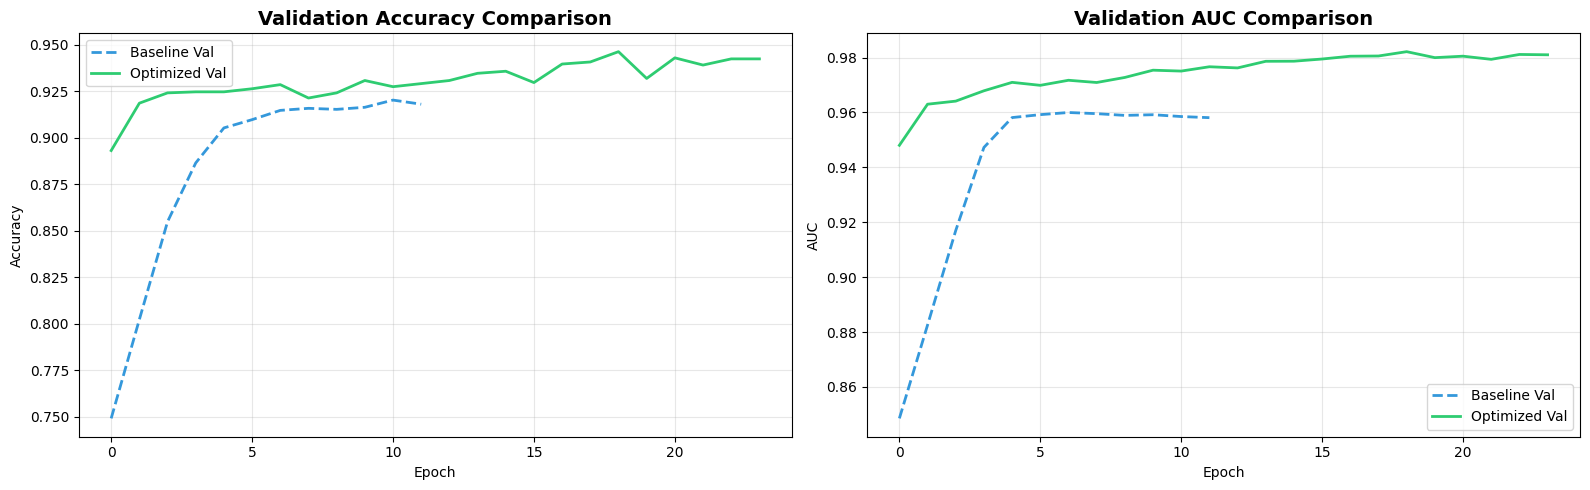

Saved: ./plots/BiGRU_Baseline_training_comparison.png


In [27]:

# Training Curves — Baseline vs Optimized


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in zip(
    axes,
    [("accuracy", "val_accuracy"), ("auc", "val_auc")],
    ["Accuracy", "AUC"],
):
    train_key, val_key = metric
    ax.plot(baseline_history.history[val_key],
            label="Baseline Val",    linewidth=2, linestyle="--", color="#3498db")
    ax.plot(optimized_history.history[val_key],
            label="Optimized Val",   linewidth=2, color="#2ecc71")
    ax.set_title(f"Validation {title} Comparison", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
train_cmp_path = f"{DIRS['plots']}/{MODEL_NAME}_training_comparison.png"
plt.savefig(train_cmp_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {train_cmp_path}")


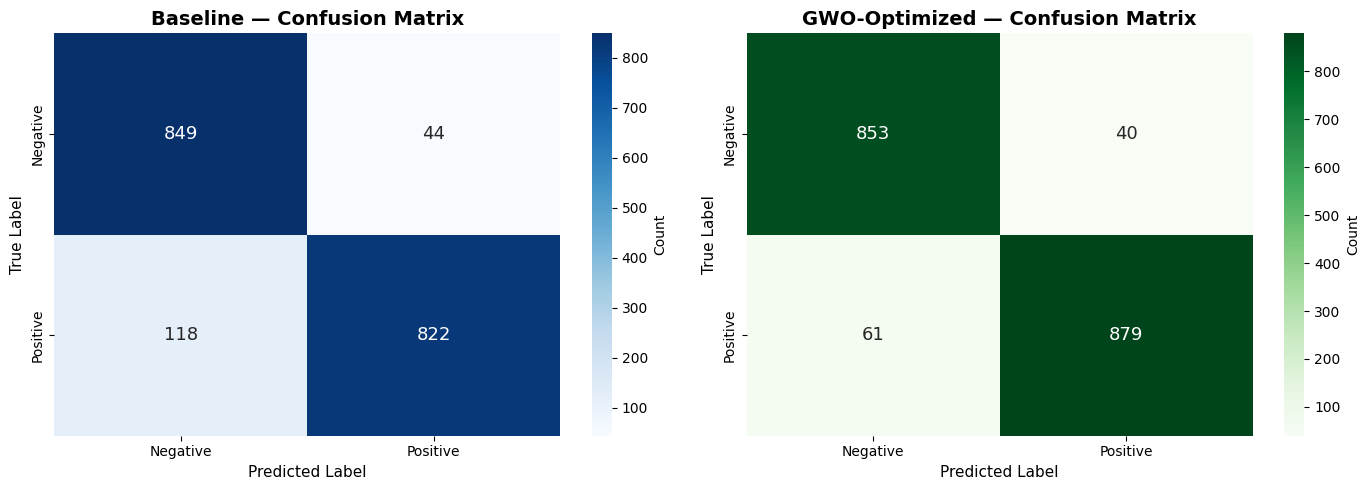

Saved: ./plots/BiGRU_Baseline_confusion_comparison.png


In [28]:

# Confusion Matrices — Baseline vs Optimized (Test Set)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm_obj, title, cmap in zip(
    axes,
    [baseline_test_metrics, optimized_test_metrics],
    ["Baseline", "GWO-Optimized"],
    ["Blues", "Greens"],
):
    sns.heatmap(
        cm_obj.confusion_matrix(), annot=True, fmt="d",
        cmap=cmap, ax=ax,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        cbar_kws={"label": "Count"}, annot_kws={"size": 13},
    )
    ax.set_title(f"{title} — Confusion Matrix", fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
cm_path = f"{DIRS['plots']}/{MODEL_NAME}_confusion_comparison.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_path}")


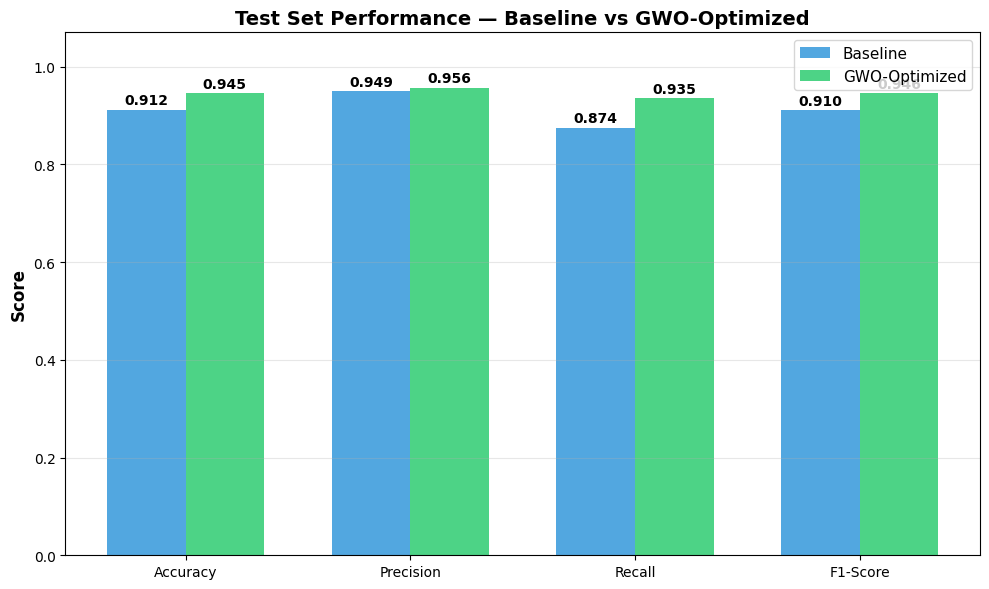

Saved: ./plots/BiGRU_Baseline_metrics_comparison.png


In [29]:

# Metrics Bar Chart — Test Set


metric_names  = ["Accuracy", "Precision", "Recall", "F1-Score"]
base_values   = [baseline_test_metrics.accuracy(), baseline_test_metrics.precision(),
                  baseline_test_metrics.recall(),   baseline_test_metrics.f1()]
opt_values    = [optimized_test_metrics.accuracy(), optimized_test_metrics.precision(),
                  optimized_test_metrics.recall(),   optimized_test_metrics.f1()]

x     = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, base_values, width, label="Baseline",      color="#3498db", alpha=0.85)
bars2 = ax.bar(x + width/2, opt_values,  width, label="GWO-Optimized", color="#2ecc71", alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Score", fontsize=12, fontweight="bold")
ax.set_title("Test Set Performance — Baseline vs GWO-Optimized", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim([0, 1.07])
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
bar_path = f"{DIRS['plots']}/{MODEL_NAME}_metrics_comparison.png"
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {bar_path}")


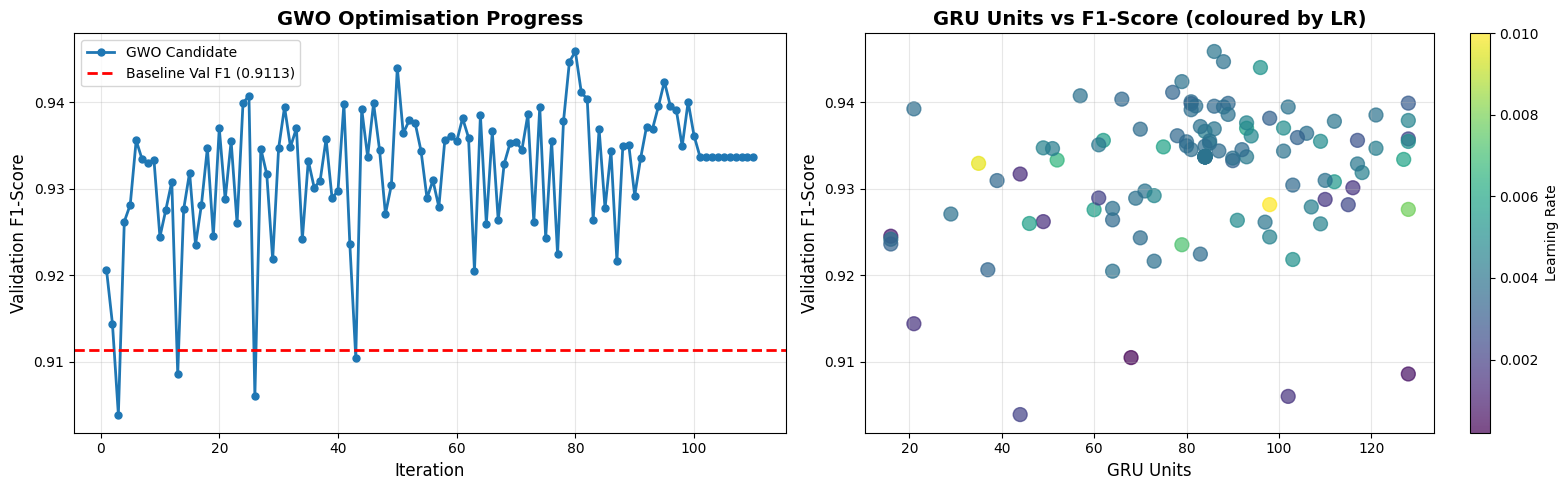

Saved: ./plots/BiGRU_Baseline_gwo_progress.png


In [30]:

# GWO Optimisation Progress


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1 over iterations
axes[0].plot(log_df["iteration"], log_df["f1_score"],
             marker="o", linewidth=2, markersize=5, label="GWO Candidate")
axes[0].axhline(y=baseline_val_metrics.f1(), color="r", linestyle="--",
                label=f"Baseline Val F1 ({baseline_val_metrics.f1():.4f})", linewidth=2)
axes[0].set_xlabel("Iteration", fontsize=12)
axes[0].set_ylabel("Validation F1-Score", fontsize=12)
axes[0].set_title("GWO Optimisation Progress", fontsize=14, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRU units vs F1 (coloured by LR)
sc = axes[1].scatter(
    log_df["gru_units"], log_df["f1_score"],
    s=100, alpha=0.7, c=log_df["learning_rate"], cmap="viridis",
)
plt.colorbar(sc, ax=axes[1], label="Learning Rate")
axes[1].set_xlabel("GRU Units", fontsize=12)
axes[1].set_ylabel("Validation F1-Score", fontsize=12)
axes[1].set_title("GRU Units vs F1-Score (coloured by LR)", fontsize=14, fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
gwo_prog_path = f"{DIRS['plots']}/{MODEL_NAME}_gwo_progress.png"
plt.savefig(gwo_prog_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {gwo_prog_path}")


In [31]:

# Final Summary

print("" + "=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)

print("[Baseline]")
print(f"  Hyperparams : LR={BASELINE_PARAMS['learning_rate']}  Batch={BASELINE_PARAMS['batch_size']}  ", end="")
print(f"GRU={BASELINE_PARAMS['gru_units']}  Drop={BASELINE_PARAMS['dropout']}")
print(f"  Test F1     : {baseline_test_metrics.f1():.4f}")
print(f"  Test Acc    : {baseline_test_metrics.accuracy():.4f}")
print(f"  Saved model : {BASELINE_MODEL_PATH}")
print(f"  Train time  : {str(timedelta(seconds=int(baseline_time)))}")

print("[GWO-Optimized]")
print(f"  Hyperparams : LR={best_params['learning_rate']:.2e}  Batch={best_params['batch_size']}  ", end="")
print(f"GRU={best_params['gru_units']}  Drop={best_params['dropout']:.4f}")
print(f"  Test F1     : {optimized_test_metrics.f1():.4f}")
print(f"  Test Acc    : {optimized_test_metrics.accuracy():.4f}")
print(f"  Saved model : {OPTIMIZED_MODEL_PATH}")
print(f"  Train time  : {str(timedelta(seconds=int(optimized_time)))}")

print(f"[Improvement]")
print(f"  F1  : {f1_improvement:+.2f}%")
print(f"  Acc : {acc_improvement:+.2f}%")
print("=" * 70)


EXPERIMENT SUMMARY
[Baseline]
  Hyperparams : LR=0.0003  Batch=256  GRU=32  Drop=0.3
  Test F1     : 0.9103
  Test Acc    : 0.9116
  Saved model : ./models/BiGRU_Baseline_baseline.keras
  Train time  : 0:01:06
[GWO-Optimized]
  Hyperparams : LR=4.02e-03  Batch=146  GRU=86  Drop=0.5000
  Test F1     : 0.9457
  Test Acc    : 0.9449
  Saved model : ./models/BiGRU_Baseline_optimized.keras
  Train time  : 0:05:16
[Improvement]
  F1  : +3.89%
  Acc : +3.65%
